In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from transformer_lens import HookedTransformer

from muutils.dictmagic import condense_tensor_dict
from muutils.dbg import dbg, dbg_tensor

In [2]:
MODEL: HookedTransformer = HookedTransformer.from_pretrained("gpt2-small")

Loaded pretrained model gpt2-small into HookedTransformer


In [10]:
prompt = """Standardised protocol for primate faecal analysis.
Macroscopic analysis of primate faeces as a way to study diet is well established, but lack of standardisation of methods may handicap comparative studies of the resulting data. Here we present a proven te"""



In [11]:
logits, cache = MODEL.run_with_cache([prompt])

In [12]:
print(condense_tensor_dict(cache, fmt="yaml"))

blocks:
  '[0-11]':
    ln1:
      hook_scale: (1, 56, 1)
      hook_normalized: (1, 56, 768)
    attn:
      '[hook_q, hook_k, hook_v, hook_z]': (1, 56, 12, 64)
      '[hook_attn_scores, hook_pattern]': (1, 12, 56, 56)
    ln2:
      hook_scale: (1, 56, 1)
      hook_normalized: (1, 56, 768)
    mlp:
      '[hook_pre, hook_post]': (1, 56, 3072)
    '[hook_resid_pre, hook_attn_out, hook_resid_mid, hook_mlp_out, hook_resid_post]': (1,
      56, 768)
ln_final:
  hook_scale: (1, 56, 1)
  hook_normalized: (1, 56, 768)
'[hook_embed, hook_pos_embed]': (1, 56, 768)



[ tmp/ipykernel_105256/3355364400.py:4 ] cache["blocks.0.attn.hook_pattern"] = shape=(1, 12, 56, 56), dtype=torch.float32, device=device(type='cuda', index=0), requires_grad=False


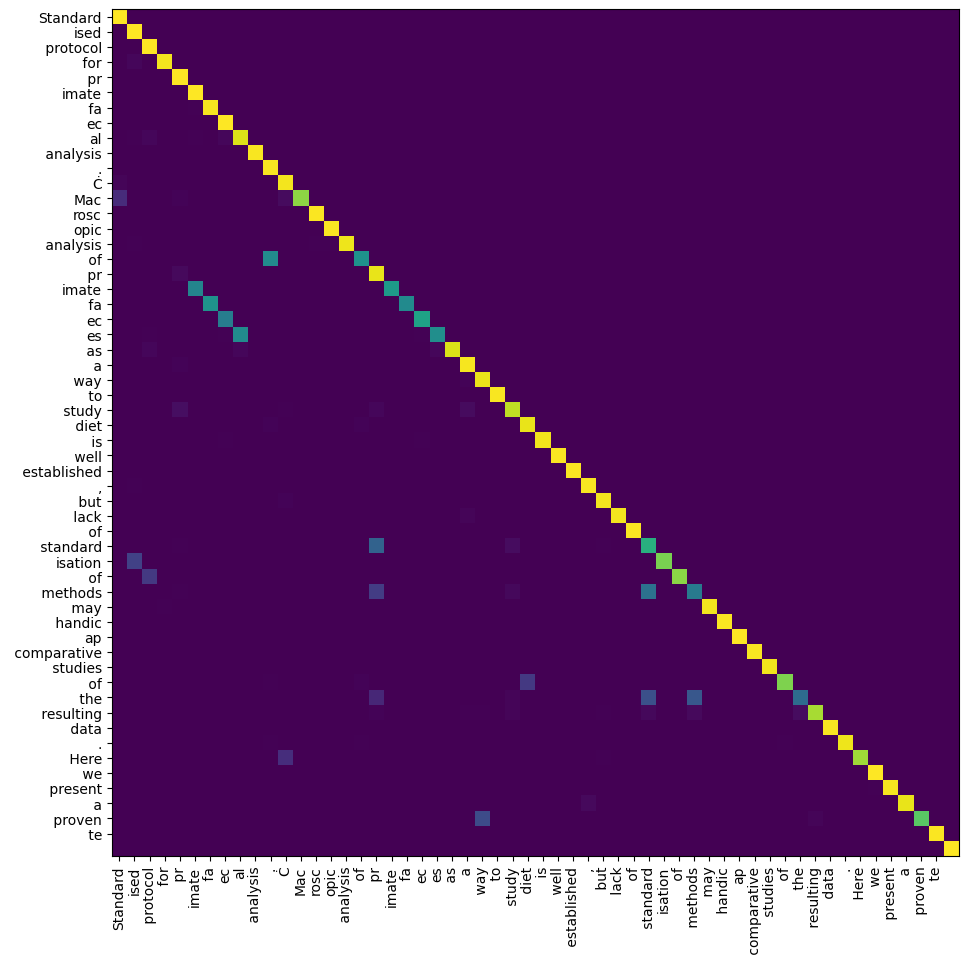

In [ ]:


dbg_tensor(cache["blocks.0.attn.hook_pattern"])


tokens: list[str] = [x.replace("Ġ", " ") for x in MODEL.tokenizer.tokenize(prompt)]
n_tokens: int = len(tokens)
figsize: float = n_tokens / 5
fig, ax = plt.subplots(figsize=(figsize,figsize))
ax.imshow(cache["blocks.0.attn.hook_pattern"][0,1].cpu().numpy())
ax.set_xticks(np.arange(len(tokens)), tokens, rotation=90)
ax.set_yticks(np.arange(len(tokens)), tokens)

print()

['Standard',
 'ised',
 'Ġprotocol',
 'Ġfor',
 'Ġpr',
 'imate',
 'Ġfa',
 'ec',
 'al',
 'Ġanalysis',
 '.',
 'Ċ',
 'Mac',
 'rosc',
 'opic',
 'Ġanalysis',
 'Ġof',
 'Ġpr',
 'imate',
 'Ġfa',
 'ec',
 'es',
 'Ġas',
 'Ġa',
 'Ġway',
 'Ġto',
 'Ġstudy',
 'Ġdiet',
 'Ġis',
 'Ġwell',
 'Ġestablished',
 ',',
 'Ġbut',
 'Ġlack',
 'Ġof',
 'Ġstandard',
 'isation',
 'Ġof',
 'Ġmethods',
 'Ġmay',
 'Ġhandic',
 'ap',
 'Ġcomparative',
 'Ġstudies',
 'Ġof',
 'Ġthe',
 'Ġresulting',
 'Ġdata',
 '.',
 'ĠHere',
 'Ġwe',
 'Ġpresent',
 'Ġa',
 'Ġproven',
 'Ġte']